# makemore Part 5 — Hierarchical Network & Convolution Preview

This notebook introduces two big ideas on top of the Part 3 MLP:

| Idea                          | What changes                                                                                                   |
| ----------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **Larger context window**     | `block_size` grows from 3 → 8 characters                                                                       |
| **Hierarchical architecture** | Instead of flattening all 8 embeddings at once, the network merges them in _pairs_ through 3 successive stages |

Three new layer classes are introduced to make this composable:

- **`Embedding`** — wraps the character lookup table as a proper layer
- **`FlattenConsecutive`** — merges every `n` adjacent time-steps into one wider vector
- **`Sequential`** — chains an arbitrary list of layers into a single model object

The notebook ends with a motivating preview of **convolutions**: when the same
model must be evaluated on many overlapping windows, a convolution is simply
the efficient "for loop" that shares those computations.

### Hierarchical architecture at a glance

```
Input  (B, 8)   — 8 character indices
  ↓ Embedding(27, 24)
(B, 8, 24)      — 8 embedding vectors

  ↓ FlattenConsecutive(2)  →  Linear(48, 128)  →  BN  →  Tanh
(B, 4, 128)     — 4 "bigram" representations

  ↓ FlattenConsecutive(2)  →  Linear(256, 128)  →  BN  →  Tanh
(B, 2, 128)     — 2 "4-gram" representations

  ↓ FlattenConsecutive(2)  →  Linear(256, 128)  →  BN  →  Tanh
(B, 128)        — single "8-gram" representation  (T=1, so dim squeezed)

  ↓ Linear(128, 27)
(B, 27)         — logits over vocabulary
```


## 1. Imports


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [ ]:
import mlflow
import os

if not os.path.exists('names.txt') and os.path.exists('../names.txt'):
    os.chdir('..')

os.makedirs('checkpoints', exist_ok=True)
mlflow.set_experiment('makemore')
_mlflow_run = mlflow.start_run(run_name='part5-hierarchical-wavenet')
print(f'MLflow run started  id={_mlflow_run.info.run_id}')

MLflow run started  id=63b69d96d94f42bfa43fea8df832bef9


## 2. Data Loading & Vocabulary

Same vocabulary as all previous parts: 26 letters + `'.'` boundary token (index 0).


In [ ]:
words = open('names.txt', 'r').read().splitlines()
print(
    f'{len(words):,} words   max length: {max(len(w) for w in words)}   examples: {words[:5]}')

chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'vocab_size = {vocab_size}')

32,033 words   max length: 15   examples: ['emma', 'olivia', 'ava', 'isabella', 'sophia']
vocab_size = 27


## 3. Dataset Construction

**Key change from Part 2/3:** `block_size` is now **8** (was 3).

A longer context window lets the model remember more history when predicting the
next character — at the cost of a larger input layer. With the hierarchical
architecture below, we handle this gracefully without multiplying hidden-layer
width by 8.


In [ ]:
block_size = 8  # context length — up from 3 in Parts 2/3


def build_dataset(words):
    """
    Slide a window of width block_size over each word to produce (context, target) pairs.
    X shape: (N, block_size)  —  integer context windows
    Y shape: (N,)             —  integer target characters
    """
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


# Shuffle once for reproducibility, then split 80 / 10 / 10
random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))

Xtr,  Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


### Dataset Inspection

Print a few `(context → target)` pairs to confirm the sliding window is correct.
The first `block_size − len(word)` context characters are padding `'.'`.


In [5]:
print('First 20 training examples:')
for x, y in zip(Xtr[:20], Ytr[:20]):
    ctx = ''.join(itos[ix.item()] for ix in x)
    print(f'  {ctx!r}  -->  {itos[y.item()]!r}')

First 20 training examples:
  '........'  -->  'y'
  '.......y'  -->  'u'
  '......yu'  -->  'h'
  '.....yuh'  -->  'e'
  '....yuhe'  -->  'n'
  '...yuhen'  -->  'g'
  '..yuheng'  -->  '.'
  '........'  -->  'd'
  '.......d'  -->  'i'
  '......di'  -->  'o'
  '.....dio'  -->  'n'
  '....dion'  -->  'd'
  '...diond'  -->  'r'
  '..diondr'  -->  'e'
  '.diondre'  -->  '.'
  '........'  -->  'x'
  '.......x'  -->  'a'
  '......xa'  -->  'v'
  '.....xav'  -->  'i'
  '....xavi'  -->  'e'


## 4. Layer Class Definitions

All layers share the same two-method interface (same as Part 3):

- `__call__(x)` — forward pass; stores result in `self.out`
- `parameters()` — returns a list of learnable tensors

**`Linear`** and **`BatchNorm1d`** are carried over from Part 3 with one upgrade
to `BatchNorm1d`: it now handles **3-D inputs** `(B, T, C)` that arise inside
the hierarchical network (before the final squeeze). When `x.ndim == 3`, it
normalises over both the batch _and_ time dimensions `(0, 1)` so each feature
channel has zero mean and unit variance across all batch × time positions.

**Three new classes are introduced in this part:**

### `Embedding`

Wraps the character lookup table as a proper layer.  
Forward: `out = weight[IX]` — index `weight` with integer indices `IX`.  
Shape: `(B, T)` of indices → `(B, T, embedding_dim)`.

### `FlattenConsecutive`

The core building block of the hierarchical design.  
Given input `(B, T, C)`, it merges every `n` adjacent time steps into one wider
vector, producing `(B, T//n, C*n)`.

```
n=2, input (B, 8, 24):
  [pos0, pos1, pos2, pos3, pos4, pos5, pos6, pos7]  (each 24-D)
→ [(pos0‖pos1), (pos2‖pos3), (pos4‖pos5), (pos6‖pos7)]  (each 48-D)
  output (B, 4, 48)
```

When the result has `T//n == 1` (only one time step left), the time dimension
is **squeezed** to `(B, C*n)` so downstream `Linear` layers receive a flat vector.

### `Sequential`

Chains an arbitrary list of layers into a single callable model.  
Forward: applies each layer in order, passing the output of one as input to the next.


In [ ]:
class Linear:
    """Affine transformation: out = x @ weight [+ bias].  Kaiming init."""

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    """
    Batch Normalization for 2-D (B, C) and 3-D (B, T, C) inputs.

    Training  : normalise over the batch dimension (and time dimension for 3-D).
    Inference : normalise using running mean/variance.
    """

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)   # scale (learnable)
        self.beta = torch.zeros(dim)  # shift (learnable)
        self.running_mean = torch.zeros(dim)  # EMA buffer
        self.running_var = torch.ones(dim)   # EMA buffer

    def __call__(self, x):
        if self.training:
            # For 3-D tensors (B, T, C): normalise over batch AND time → dim (0,1)
            # For 2-D tensors (B, C)   : normalise over batch only   → dim 0
            dim = (0, 1) if x.ndim == 3 else 0
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim,  keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * \
                    self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * \
                    self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    """Element-wise hyperbolic tangent activation."""

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


class Embedding:
    """
    Lookup table that maps integer token indices to dense vectors.

    Forward: out = weight[IX]
    Input  IX shape: (B, T)  — integer indices
    Output shape   : (B, T, embedding_dim)
    """

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]


class FlattenConsecutive:
    """
    Merge every n consecutive time steps into one wider vector.

    Input  (B, T, C)  →  Output (B, T//n, C*n)
    If T//n == 1 after merging, the time dimension is squeezed:
    Output becomes (B, C*n) — a flat vector per example.

    This is the key operation that enables the hierarchical tree structure.
    """

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        # merge n consecutive positions
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            # remove time dim when only 1 step left
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []


class Sequential:
    """
    Chains a list of layers into a single model.
    Forward: applies each layer in order, x → layer1 → layer2 → … → output.
    """

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        # Collect parameters from every layer into one flat list
        return [p for layer in self.layers for p in layer.parameters()]

## 5. Model Architecture

### Flat vs. Hierarchical

**Flat (original, commented out below):** one `FlattenConsecutive(8)` concatenates
all 8 embeddings into a single `8×24 = 192`-dimensional vector, then passes it
through one large linear layer. The input layer sees all positions at once, but
there is no inductive bias toward local structure.

**Hierarchical (active):** three stages of `FlattenConsecutive(2)` merge positions
in pairs: first bigrams, then 4-grams, then 8-grams. This mirrors how language
has local structure — adjacent characters form syllables, which form morphemes,
which form words. The total parameter count stays roughly the same (~76 K) but
the network can learn increasingly abstract representations at each level.

### Shape trace through the hierarchical network

| Stage     | Layer                         | Output shape                          |
| --------- | ----------------------------- | ------------------------------------- |
| Input     | —                             | `(B, 8)`                              |
| Embedding | `Embedding(27, 24)`           | `(B, 8, 24)`                          |
| Stage 1   | `FlattenConsecutive(2)`       | `(B, 4, 48)`                          |
|           | `Linear(48→128)` + BN + Tanh  | `(B, 4, 128)`                         |
| Stage 2   | `FlattenConsecutive(2)`       | `(B, 2, 256)`                         |
|           | `Linear(256→128)` + BN + Tanh | `(B, 2, 128)`                         |
| Stage 3   | `FlattenConsecutive(2)`       | `(B, 1, 256)` → squeezed → `(B, 256)` |
|           | `Linear(256→128)` + BN + Tanh | `(B, 128)`                            |
| Output    | `Linear(128→27)`              | `(B, 27)`                             |


In [ ]:
torch.manual_seed(42)

n_embd = 24   # character embedding dimension
n_hidden = 128  # hidden layer width at each stage

# Hierarchical model (active)
# Each stage: FlattenConsecutive(2) merges pairs → Linear → BN → Tanh
model = Sequential([
    Embedding(vocab_size, n_embd),
    # Stage 1 — bigrams: 8 positions → 4
    FlattenConsecutive(2), Linear(n_embd * 2,   n_hidden,
                                  bias=False), BatchNorm1d(n_hidden), Tanh(),
    # Stage 2 — 4-grams: 4 positions → 2
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden,
                                  bias=False), BatchNorm1d(n_hidden), Tanh(),
    # Stage 3 — 8-gram : 2 positions → 1 (squeezed)
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden,
                                  bias=False), BatchNorm1d(n_hidden), Tanh(),
    # Output head
    Linear(n_hidden, vocab_size),
])

# Flat model (for comparison — uncomment to try)
# model = Sequential([
#     Embedding(vocab_size, n_embd),
#     FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, vocab_size),
# ])

# Make the output layer less confident at initialization
with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
for p in parameters:
    p.requires_grad = True

print(f'Total parameters: {sum(p.nelement() for p in parameters):,}')

Total parameters: 76,579


### Verify Intermediate Shapes

Confirm that activations flow through the network with the expected shapes.


In [8]:
with torch.no_grad():
    x = Xtr[:4]  # small batch
    print(f'Input:  {tuple(x.shape)}')
    for i, layer in enumerate(model.layers):
        x = layer(x)
        print(f'  [{i:2d}] {layer.__class__.__name__:20s} → {tuple(x.shape)}')

Input:  (4, 8)
  [ 0] Embedding            → (4, 8, 24)
  [ 1] FlattenConsecutive   → (4, 4, 48)
  [ 2] Linear               → (4, 4, 128)
  [ 3] BatchNorm1d          → (4, 4, 128)
  [ 4] Tanh                 → (4, 4, 128)
  [ 5] FlattenConsecutive   → (4, 2, 256)
  [ 6] Linear               → (4, 2, 128)
  [ 7] BatchNorm1d          → (4, 2, 128)
  [ 8] Tanh                 → (4, 2, 128)
  [ 9] FlattenConsecutive   → (4, 256)
  [10] Linear               → (4, 128)
  [11] BatchNorm1d          → (4, 128)
  [12] Tanh                 → (4, 128)
  [13] Linear               → (4, 27)


## 6. Training Loop

Same mini-batch SGD as Parts 2–4. The training loop itself is unchanged —
the complexity was absorbed into the `Sequential` model object.

Learning rate schedule: `lr = 0.1` for the first 150 k steps, then `lr = 0.01`.


In [ ]:
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):

    # 1. Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # 2. Forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # 3. Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # 4. SGD update
    lr = 0.1 if i < 150_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10_000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/200000: 3.3167


  10000/200000: 2.0576


  20000/200000: 2.0723


  30000/200000: 2.5134


  40000/200000: 2.1476


...

 150000/200000: 1.7466


 160000/200000: 1.8806


 170000/200000: 1.6266


 180000/200000: 1.6476


 190000/200000: 1.8555


### Training Loss Curve

We group the per-step losses into bins of 1 000 and plot the mean,
which smooths out mini-batch noise while preserving the trend.


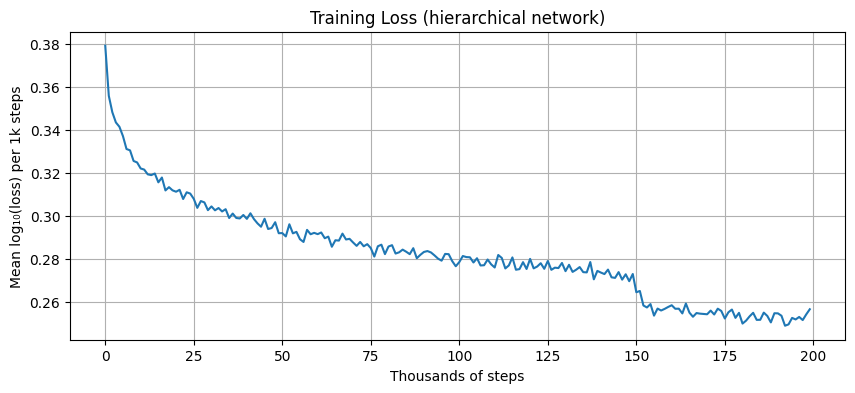

In [10]:
# Reshape into (num_bins, 1000) and average each bin
smoothed = torch.tensor(lossi).view(-1, 1000).mean(1)

plt.figure(figsize=(10, 4))
plt.plot(smoothed)
plt.xlabel('Thousands of steps')
plt.ylabel('Mean log\u2081\u2080(loss) per 1k steps')
plt.title('Training Loss (hierarchical network)')
plt.grid(True)
plt.show()

## 7. Evaluation

Switch all layers to **eval mode** first — this tells `BatchNorm1d` to use its
running mean/variance instead of computing per-batch statistics.


In [ ]:
# Switch every layer to inference mode
for layer in model.layers:
    layer.training = False


@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev),
            'test': (Xte, Yte)}[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(f'{split:6s} loss: {loss.item():.4f}')


split_loss('train')
split_loss('val')

train  loss: 1.7690
val    loss: 1.9937


### Performance Log

Each row below shows one incremental change and the resulting train / val loss.
The progression isolates the contribution of each architectural decision.

| Configuration                               | Params   | Train     | Val       |
| ------------------------------------------- | -------- | --------- | --------- |
| Baseline: Part 3 (context=3, hidden=200)    | 12 K     | 2.058     | 2.105     |
| Context 3 → 8 (flat, hidden=300)            | 22 K     | 1.918     | 2.027     |
| Flat → hierarchical (n_embd=10, hidden=300) | 22 K     | 1.941     | 2.029     |
| Fix BN bug (3-D normalisation dim)          | 22 K     | 1.912     | 2.022     |
| **Scale up (n_embd=24, n_hidden=128)**      | **76 K** | **1.769** | **1.993** |

Key takeaways:

- A longer context window alone gives a big jump (2.105 → 2.027)
- Switching to a hierarchical architecture barely changes the result at the same
  parameter count, but enables scaling to deeper, wider networks
- Scaling the hierarchical network to 76 K params pushes val loss below 2.0 for the first time


## 8. Name Generation

Autoregressively sample 20 names from the trained model.
Layers remain in eval mode from the previous cell.


In [ ]:
g_sample = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out[:-1]))

carmah
amelle
khyrill
reity
skanden
jazzuel
amerync
kaeli
nellaritze
iivon
legynd
brooklynne
juliani
raina
bisorte
madiaryn
kaidencius
brex
edi
abettaley


---
## 9. Preview: Why Convolutions?

The cells below build intuition for *why* convolutions exist and what problem
they solve.  No convolution is actually implemented here — that comes in Part 6.

### The inefficiency of overlapping windows

Consider 8 consecutive rows in the training set.  They correspond to the same
underlying sequence shifted by one position each:

```
row 7:  [c0, c1, c2, c3, c4, c5, c6, c7]  →  target t7
row 8:  [c1, c2, c3, c4, c5, c6, c7, c8]  →  target t8
row 9:  [c2, c3, c4, c5, c6, c7, c8, c9]  →  target t9
...

and so on

```

These windows overlap by 7 out of 8 positions.  When we run our model on each
example **separately** (the for-loop below), we recompute the lower-level
representations for those shared positions from scratch each time — a lot of
redundant work.

A **convolution** avoids this by treating the entire sequence as one tensor and
sliding the weight matrix over it in a single parallel operation.  Each position
in the output is computed once, even though it would appear in multiple overlapping
windows.
```


In [13]:
# Inspect the 8 consecutive training examples starting at index 7
# Notice how each row is the previous row shifted one position to the right
print('8 consecutive examples (each shifted by 1 position):')
for x, y in zip(Xtr[7:15], Ytr[7:15]):
    ctx = ''.join(itos[ix.item()] for ix in x)
    print(f'  {ctx!r}  -->  {itos[y.item()]!r}')

8 consecutive examples (each shifted by 1 position):
  '........'  -->  'd'
  '.......d'  -->  'i'
  '......di'  -->  'o'
  '.....dio'  -->  'n'
  '....dion'  -->  'd'
  '...diond'  -->  'r'
  '..diondr'  -->  'e'
  '.diondre'  -->  '.'


In [ ]:
# Forward a single example — model produces one logit vector
logits_single = model(Xtr[[7]])
print(
    f'Single forward pass: input {tuple(Xtr[[7]].shape)}  →  logits {tuple(logits_single.shape)}')

Single forward pass: input (1, 8)  →  logits (1, 27)


In [15]:
# Forward all 8 examples one at a time — the naive "for loop" approach
# Each pass is completely independent: shared sub-sequences are re-computed 7 times
logits_loop = torch.zeros(8, vocab_size)
for i in range(8):
    logits_loop[i] = model(Xtr[[7 + i]])

print(f'8 separate forward passes → logits shape: {tuple(logits_loop.shape)}')

8 separate forward passes → logits shape: (8, 27)


### The convolution insight

```
for-loop approach (above):
  Run the full model 8 times.  Each run processes 8 positions.
  Total work: 8 × 8 = 64 position-evaluations.

convolution (Part 6):
  Run the model once over the whole sequence of length 15.
  Total work: ~15 position-evaluations.
```

A convolution is literally a **`Linear` layer applied at every position** via a
shared weight matrix. PyTorch implements this as `F.conv1d`, which does the
sliding-window linear projection in a single CUDA kernel — far more efficient
than Python loops.

The hierarchical `FlattenConsecutive` + `Linear` blocks we built in this part are
**already convolutions** — just written as explicit reshapes + matmuls rather than
using the `conv1d` API. Part 6 will rewrite them using `F.conv1d` and show they
produce identical outputs.


In [ ]:
# MLflow: log params, metrics, and model checkpoint
import torch

# Make sure all layers are in eval mode for correct inference
for layer in model.layers:
    layer.training = False


@torch.no_grad()
def _eval(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    logits = model(x)
    return F.cross_entropy(logits, y).item()


train_loss = _eval('train')
val_loss = _eval('val')

mlflow.log_params({
    'block_size': block_size,
    'n_embd':     n_embd,
    'n_hidden':   n_hidden,
    'max_steps':  max_steps,
    'batch_size': batch_size,
    'vocab_size': vocab_size,
    'architecture': 'hierarchical-wavenet',
    'num_stages':   3,
})
mlflow.log_metric('train_loss', train_loss)
mlflow.log_metric('val_loss',   val_loss)

# Save all learnable parameters from the Sequential model
ckpt_path = 'checkpoints/part5_wavenet.pt'
torch.save({
    'model_params': [p.data for p in model.parameters()],
    'stoi':         stoi,
    'itos':         itos,
    'block_size':   block_size,
    'n_embd':       n_embd,
    'n_hidden':     n_hidden,
}, ckpt_path)
mlflow.log_artifact(ckpt_path)

mlflow.end_run()
print(
    f'MLflow run complete  train={train_loss:.4f}  val={val_loss:.4f}  ckpt={ckpt_path}')

MLflow run complete  train=1.7690  val=1.9937  ckpt=checkpoints/part5_wavenet.pt
